# **패혈증 진단 예측 모델**

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

# 드라이브 마운트
drive.mount('/content/drive')

# 1. 파일이 저장된 정확한 경로 (본인의 경로에 맞게 수정하세요)
base_path = '/content/drive/MyDrive/ColabNotebooks/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


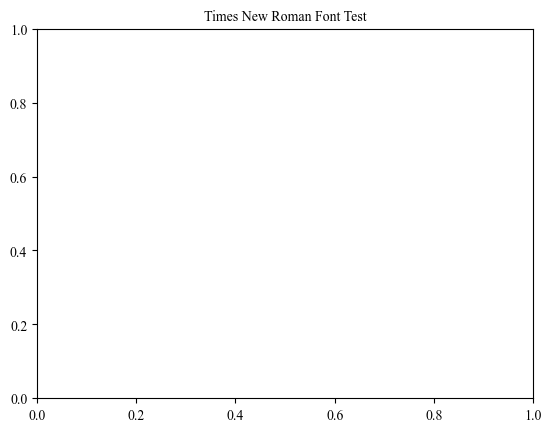

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 파일의 경로를 직접 입력
font_path = '/content/drive/MyDrive/TimesNewerRoman/Times New Roman.ttf'

# 폰트를 Matplotlib 폰트 관리자에 추가
fm.fontManager.addfont(font_path)

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()

# 테스트
plt.title("Times New Roman Font Test", fontproperties=font_prop)
plt.show()

✅ 데이터 준비 완료 (사용한 변수 개수: 44개)

[모델 학습 시작]
✅ Random Forest: AUC=0.8655, Best Threshold=0.0296


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:37:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost: AUC=0.8442, Best Threshold=0.0512
✅ LightGBM: AUC=0.8801, Best Threshold=0.1719
✅ Logistic Regression: AUC=0.8619, Best Threshold=0.2778


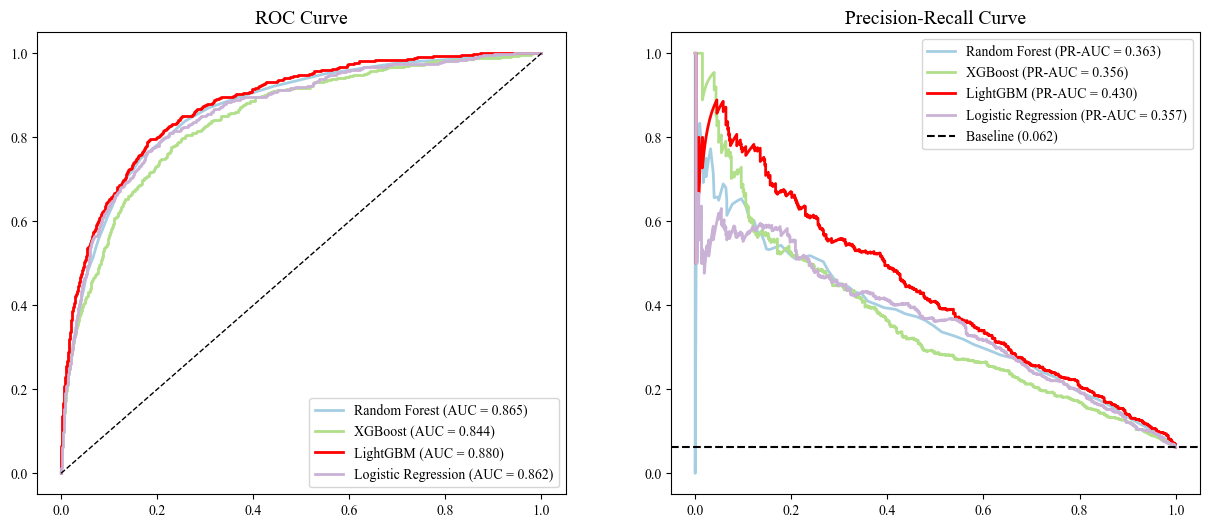

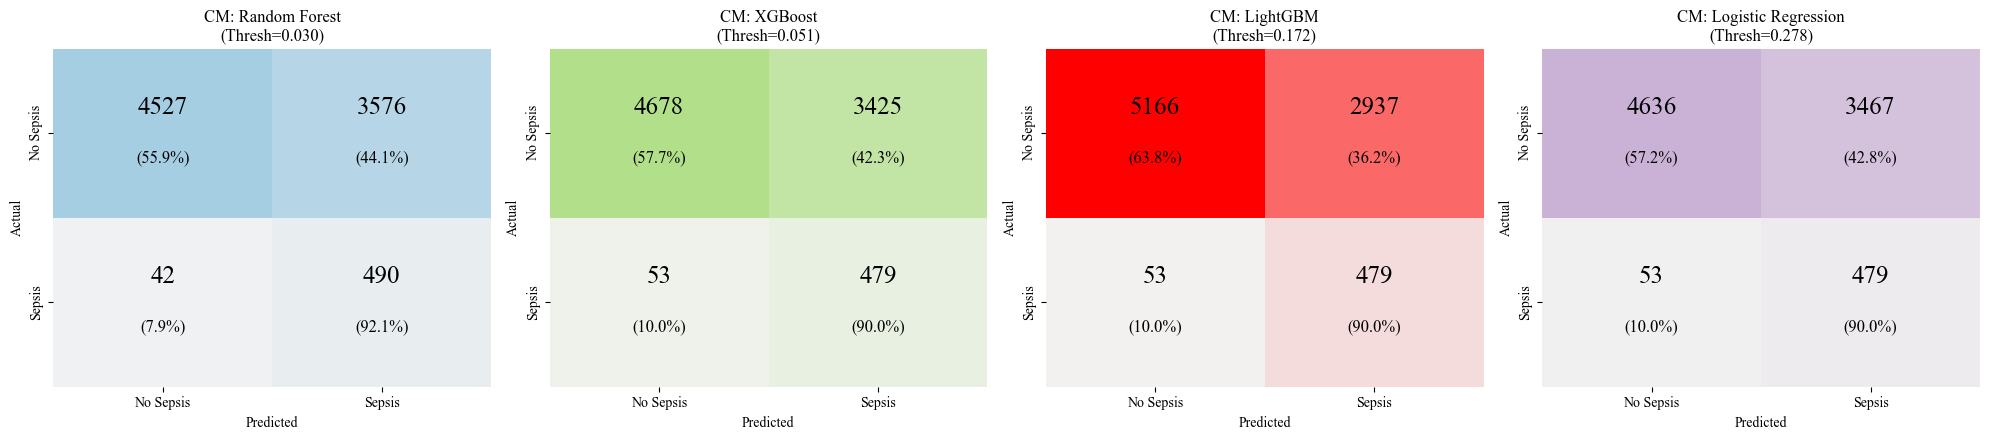


로지스틱 회귀: Odds Ratio (OR) 분석
                   Feature        OR      Coef
33      RESP_RATE_measured  1.891721  0.637487
0                      WBC  1.651643  0.501770
12        AGE_AT_ADMISSION  1.491975  0.400101
5                   SODIUM  1.347014  0.297890
43  URINE_PROTEIN_measured  1.307404  0.268043
34           TEMP_measured  1.254280  0.226562
37           PAO2_measured  1.203106  0.184906
22              HEART_RATE  1.160675  0.149002
13                  GENDER  1.131300  0.123367
17                     INR  1.126040  0.118707
38           FIO2_measured  1.124845  0.117645
25                     MAP  1.121012  0.114232
26               RESP_RATE  1.118196  0.111717
14                 LACTATE  1.102754  0.097811
3               CREATININE  1.088162  0.084490

로지스틱 회귀 Threshold 최적화 비교
       Method  Threshold  Precision  Recall      F1  Specificity
0     Default     0.5000     0.2112  0.7707  0.3316       0.8111
1      Max F1     0.7524     0.3633  0.5470  0.4366       0.937

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


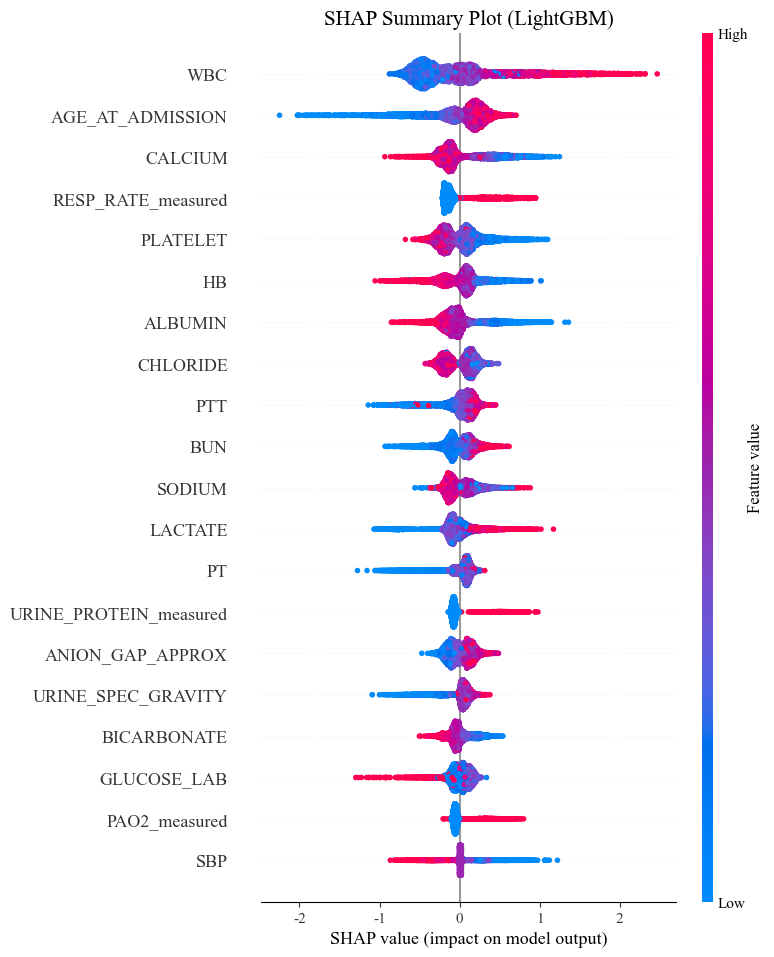


🎯 분석 요약
  - Random Forest: AUC=0.8655, PR-AUC=0.3629, Recall=0.9211, Accuracy=0.5810
  - XGBoost: AUC=0.8442, PR-AUC=0.3559, Recall=0.9004, Accuracy=0.5972
  - LightGBM: AUC=0.8801, PR-AUC=0.4301, Recall=0.9004, Accuracy=0.6537
  - Logistic Regression: AUC=0.8619, PR-AUC=0.3572, Recall=0.9004, Accuracy=0.5924
주요 사망 위험 요인(OR 상위): RESP_RATE_measured (OR: 1.89)


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    classification_report, accuracy_score, precision_recall_curve,
    auc, f1_score, recall_score, precision_score
)
# 0. 설정 및 색상
base_path = '/content/drive/MyDrive/ColabNotebooks/'
color_list = ["#A6CEE3", "#B2DF8A", "#FDBF6F", "#CAB2D6", "#FB9A99"]
model_colors = {
    'Random Forest': color_list[0],
    'XGBoost': color_list[1],
    'LightGBM': 'red',
    'Logistic Regression': color_list[3]
}
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터 로드
train_df = pd.read_csv(f'{base_path}cohort_csv/train_final.csv')
test_df = pd.read_csv(f'{base_path}cohort_csv/test_final.csv')

# 2. 변수 분류 및 전처리 (패혈증 모델이므로 'HOSPITAL_EXPIRE_FLAG' 제외)
target = 'SEPSIS'
exclude_vars = [target, 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'HOSPITAL_EXPIRE_FLAG']
feature_cols = [c for c in train_df.columns if c not in exclude_vars]

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

# 로지스틱 회귀를 위한 스케일링
schaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print(f"✅ 데이터 준비 완료 (사용한 변수 개수: {len(feature_cols)}개)")

# 3. 모델 정의 및 학습
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42), # Corrected LightGBM definition
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
}

results = {}

print("\n[모델 학습 시작]")
for name, model in models_dict.items():
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train
    cur_X_test = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(cur_X_train, y_train)
    y_prob = model.predict_proba(cur_X_test)[:, 1]

    # Recall 0.9 기반 최적 임계값 찾기 (for the current model)
    recalls = [recall_score(y_test, (y_prob >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
    valid_idx = np.where(np.array(recalls) >= 0.90)[0]
    best_threshold = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5 # Using 0.5 as fallback

    # 최적 임계값으로 예측 (for the current model)
    y_pred_optimal = (y_prob >= best_threshold).astype(int)

    # Calculate precision and recall for PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    results[name] = {
        'prob': y_prob,
        'pred': y_pred_optimal,
        'threshold': best_threshold,
        'auc': roc_auc_score(y_test, y_prob),
        'pr_auc': auc(recall, precision),
        'recall': recall_score(y_test, y_pred_optimal),
        'accuracy': accuracy_score(y_test, y_pred_optimal),
        'model': model
    }
    print(f"✅ {name}: AUC={results[name]['auc']:.4f}, Best Threshold={best_threshold:.4f}")

# 4-1. 시각화 (ROC & PRC)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for name, res in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=model_colors[name], lw=2)

    # PRC Curve
    precision, recall, _ = precision_recall_curve(y_test, res['prob'])
    ax2.plot(recall, precision, label=f"{name} (PR-AUC = {res['pr_auc']:.3f})", color=model_colors[name], lw=2)

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Curve', fontsize=14)
ax1.legend()

no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.axhline(y=no_skill, color='k', linestyle='--', label=f'Baseline ({no_skill:.3f})')
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.legend()
plt.show()

# 4-2. 시각화: Confusion Matrix (최적 임계값 반영)
fig, axes = plt.subplots(1, len(results), figsize=(len(results) * 5, 4.5))
# Ensure axes is always iterable, even if there's only one subplot
if len(results) == 1:
    axes = [axes]

for i, (name, res) in enumerate(results.items()):
    ax = axes[i] # Get the current subplot axis
    cm = confusion_matrix(y_test, res['pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Calculate percentages

    cmap = sns.light_palette(model_colors[name], as_cmap=True)
    sns.heatmap(cm, annot=False, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['No Sepsis','Sepsis'], yticklabels=['No Sepsis','Sepsis'])

    # Manually add annotations with different font sizes and positions
    for (j, k), count in np.ndenumerate(cm):
        percentage = cm_norm[j, k]
        ax.text(k + 0.5, j + 0.35, f"{count}",
                ha='center', va='center', fontsize=18, color='black', fontweight='bold') # Large, bold count
        ax.text(k + 0.5, j + 0.65, f"({percentage:.1%})",
                ha='center', va='center', fontsize=12, color='black') # Smaller percentage

    ax.set_title(f"CM: {name}\n(Thresh={res['threshold']:.3f})", fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Save each confusion matrix plot
    plt.savefig(f'{figures_path}/confusion_matrix_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

# 5. 로지스틱 회귀 Odds Ratio 분석
print("\n" + "="*80)
print("로지스틱 회귀: Odds Ratio (OR) 분석")
lr_res = results['Logistic Regression']
or_df = pd.DataFrame({
    'Feature': feature_cols,
    'OR': np.exp(lr_res['model'].coef_[0]),
    'Coef': lr_res['model'].coef_[0]
}).sort_values(by='OR', ascending=False)
print(or_df.head(15))

# 6. 로지스틱 회귀 전용 Threshold 비교
print("\n" + "="*80)
print("로지스틱 회귀 Threshold 최적화 비교")
y_test_proba = lr_res['prob']
thresh_results = []

f1_scores = [f1_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 100)]
best_f1_t = np.linspace(0.01, 0.99, 100)[np.argmax(f1_scores)]

recalls = [recall_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx = np.where(np.array(recalls) >= 0.90)[0]
best_rec_t = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5

for m_name, t_val in [('Default', 0.5), ('Max F1', best_f1_t), ("Youden's J", lr_res['threshold']), ('Recall 0.9', best_rec_t)]:
    preds = (y_test_proba >= t_val).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    thresh_results.append({
        'Method': m_name, 'Threshold': round(t_val, 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1': round(f1_score(y_test, preds), 4),
        'Specificity': round(tn/(tn+fp), 4)
    })
print(pd.DataFrame(thresh_results))

# 7. SHAP 해석 (LightGBM 기준)
print("\n" + "="*80)
print("SHAP 해석 (LightGBM 기준)")
explainer = shap.TreeExplainer(results['LightGBM']['model'])
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):shap_values = shap_values[1]

plt.figure(figsize=(10, 6))
# 별도의 이름 매핑 없이 원본 X_test 사용 (컬럼명이 자동으로 들어감)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (LightGBM)", fontsize=15)
plt.show()

# 최종 요약
print("\n" + "="*80)
print("🎯 분석 요약")
for name, res in results.items():
    print(f"  - {name}: AUC={res['auc']:.4f}, PR-AUC={res['pr_auc']:.4f}, Recall={res['recall']:.4f}, Accuracy={res['accuracy']:.4f}")
print(f"주요 사망 위험 요인(OR 상위): {or_df.iloc[0]['Feature']} (OR: {or_df.iloc[0]['OR']:.2f})")

In [ ]:
print("\n" + "="*80)
print("훈련 데이터셋 성능 평가 (과적합 확인)")

train_results = {}

for name, res in results.items():
    model = res['model']

    # 로지스틱 회귀는 스케일링된 데이터를 사용해야 함
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train

    y_prob_train = model.predict_proba(cur_X_train)[:, 1]

    precision_train, recall_train, _ = precision_recall_curve(y_train, y_prob_train)

    train_results[name] = {
        'auc_train': roc_auc_score(y_train, y_prob_train),
        'pr_auc_train': auc(recall_train, precision_train)
    }
    print(f"✅ {name:20}: Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}")

print("\n" + "="*80)
print("🎯 최종 비교: 훈련 vs. 테스트 성능")
for name, res in results.items():
    print(f"  - {name}:\n    Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}\n    Test AUC={res['auc']:.4f}, Test PR-AUC={res['pr_auc']:.4f}")
    if train_results[name]['auc_train'] - res['auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train AUC와 Test AUC 차이: {:.2f})".format(train_results[name]['auc_train'] - res['auc']))
    if train_results[name]['pr_auc_train'] - res['pr_auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: {:.2f})".format(train_results[name]['pr_auc_train'] - res['pr_auc']))


훈련 데이터셋 성능 평가 (과적합 확인)
✅ Random Forest       : Train AUC=1.0000, Train PR-AUC=1.0000
✅ XGBoost             : Train AUC=0.9971, Train PR-AUC=0.9595
✅ LightGBM            : Train AUC=0.9700, Train PR-AUC=0.7025
✅ Logistic Regression : Train AUC=0.8610, Train PR-AUC=0.3300

🎯 최종 비교: 훈련 vs. 테스트 성능
  - Random Forest:
    Train AUC=1.0000, Train PR-AUC=1.0000
    Test AUC=0.8655, Test PR-AUC=0.3629
    ⚠️  과적합이 의심됩니다. (Train AUC와 Test AUC 차이: 0.13)
    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: 0.64)
  - XGBoost:
    Train AUC=0.9971, Train PR-AUC=0.9595
    Test AUC=0.8442, Test PR-AUC=0.3559
    ⚠️  과적합이 의심됩니다. (Train AUC와 Test AUC 차이: 0.15)
    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: 0.60)
  - LightGBM:
    Train AUC=0.9700, Train PR-AUC=0.7025
    Test AUC=0.8801, Test PR-AUC=0.4301
    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: 0.27)
  - Logistic Regression:
    Train AUC=0.8610, Train PR-AUC=0.3300
    Test AUC=0.8619, Test PR-AUC=0.3572


✅ 데이터 준비 완료 (사용한 변수 개수: 44개)

[모델 학습 시작]
✅ Random Forest: AUC=0.8577, Best Threshold=0.3308
✅ XGBoost: AUC=0.8849, Best Threshold=0.2739
✅ LightGBM: AUC=0.8854, Best Threshold=0.2739
✅ Logistic Regression: AUC=0.8619, Best Threshold=0.2778


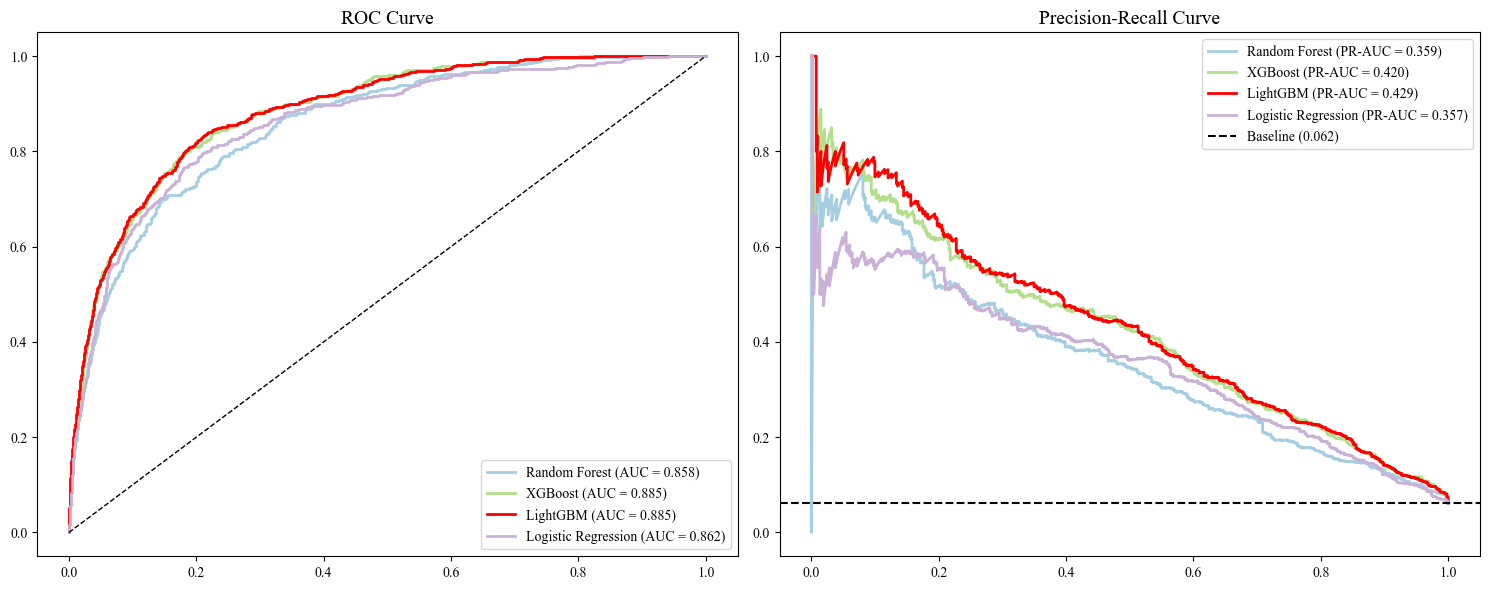

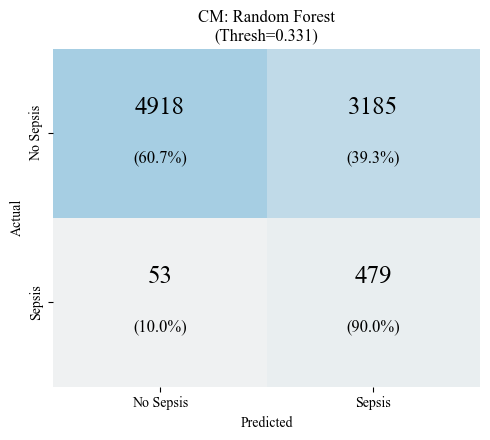

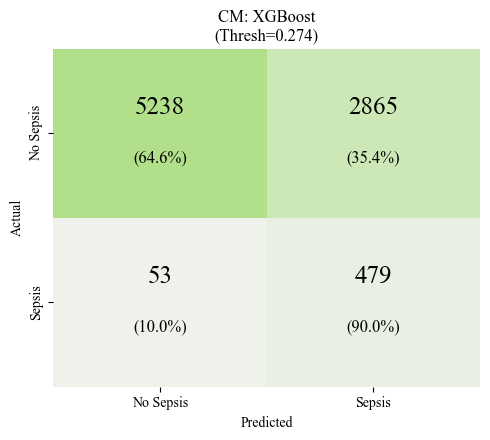

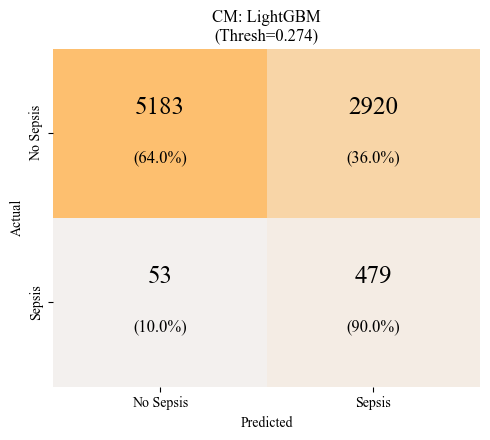

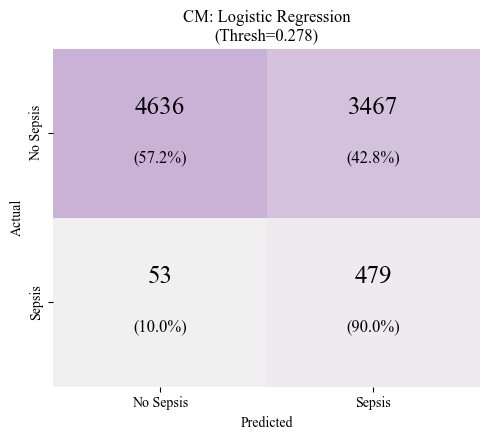


로지스틱 회귀: Odds Ratio (OR) 분석
                   Feature        OR      Coef
33      RESP_RATE_measured  1.891721  0.637487
0                      WBC  1.651643  0.501770
12        AGE_AT_ADMISSION  1.491975  0.400101
5                   SODIUM  1.347014  0.297890
43  URINE_PROTEIN_measured  1.307404  0.268043
34           TEMP_measured  1.254280  0.226562
37           PAO2_measured  1.203106  0.184906
22              HEART_RATE  1.160675  0.149002
13                  GENDER  1.131300  0.123367
17                     INR  1.126040  0.118707
38           FIO2_measured  1.124845  0.117645
25                     MAP  1.121012  0.114232
26               RESP_RATE  1.118196  0.111717
14                 LACTATE  1.102754  0.097811
3               CREATININE  1.088162  0.084490

로지스틱 회귀 Threshold 최적화 비교
       Method  Threshold  Precision  Recall      F1  Specificity
0     Default     0.5000     0.2112  0.7707  0.3316       0.8111
1      Max F1     0.7524     0.3633  0.5470  0.4366       0.937

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


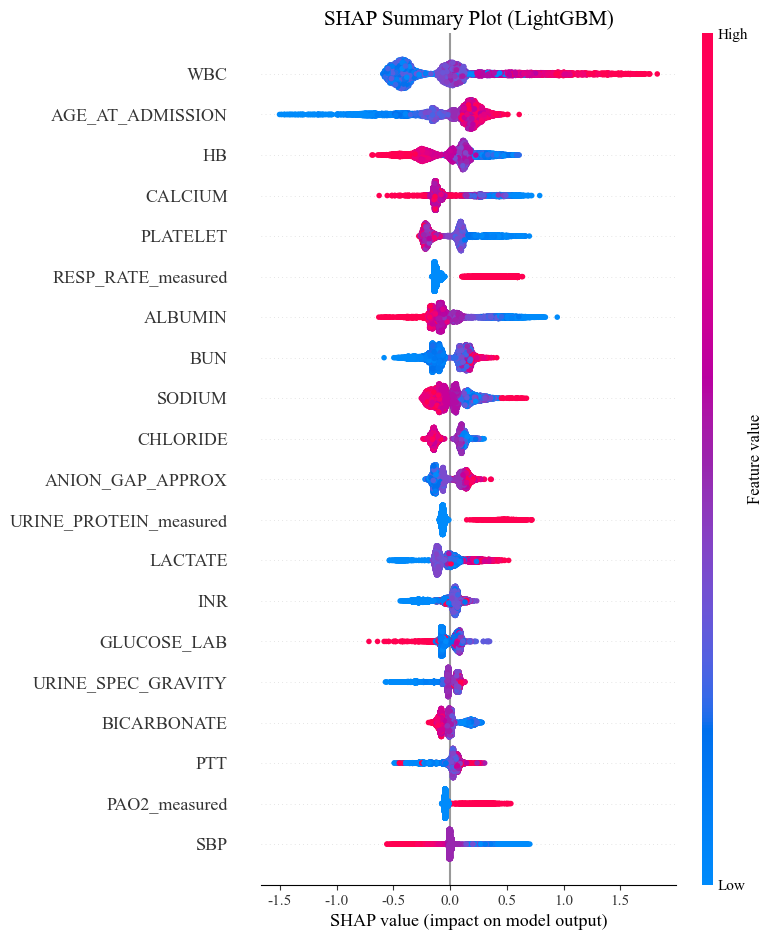


🎯 분석 요약
  - Random Forest: AUC=0.8577, PR-AUC=0.3594, Recall=0.9004, Accuracy=0.6250
  - XGBoost: AUC=0.8849, PR-AUC=0.4199, Recall=0.9004, Accuracy=0.6621
  - LightGBM: AUC=0.8854, PR-AUC=0.4294, Recall=0.9004, Accuracy=0.6557
  - Logistic Regression: AUC=0.8619, PR-AUC=0.3572, Recall=0.9004, Accuracy=0.5924
주요 사망 위험 요인(OR 상위): RESP_RATE_measured (OR: 1.89)


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    classification_report, accuracy_score, precision_recall_curve,
    auc, f1_score, recall_score, precision_score
)

# 0. 설정 및 색상
base_path = '/content/drive/MyDrive/ColabNotebooks/'
figures_path = f'{base_path}figures'
os.makedirs(figures_path, exist_ok=True) # Create directory if it doesn't exist

color_list = ["#A6CEE3", "#B2DF8A", "#FDBF6F", "#CAB2D6", "#FB9A99"]
model_colors = {
    'Random Forest': color_list[0],
    'XGBoost': color_list[1],
    'LightGBM': 'red',
    'Logistic Regression': color_list[3]
}
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터 로드
train_df = pd.read_csv(f'{base_path}cohort_csv/train_final.csv')
test_df = pd.read_csv(f'{base_path}cohort_csv/test_final.csv')

# 2. 변수 분류 및 전처리 (패혈증 모델이므로 'HOSPITAL_EXPIRE_FLAG' 제외)
target = 'SEPSIS'
exclude_vars = [target, 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'HOSPITAL_EXPIRE_FLAG']
feature_cols = [c for c in train_df.columns if c not in exclude_vars]

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

# 로지스틱 회귀를 위한 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print(f"✅ 데이터 준비 완료 (사용한 변수 개수: {len(feature_cols)}개)")


# 3. 모델 정의 및 학습
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=500, learning_rate=0.03, importance_type='gain', class_weight='balanced', random_state=42, verbose=-1, max_depth=3, num_leaves=7, min_child_samples=50, lambda_l1=1.0),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
}

results = {}

print("\n[모델 학습 시작]")
for name, model in models_dict.items():
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train
    cur_X_test = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(cur_X_train, y_train)
    y_prob = model.predict_proba(cur_X_test)[:, 1]

    # Recall 0.9 기반 최적 임계값 찾기 (for the current model)
    recalls = [recall_score(y_test, (y_prob >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
    valid_idx = np.where(np.array(recalls) >= 0.90)[0]
    best_threshold = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5 # Using 0.5 as fallback

    # 최적 임계값으로 예측 (for the current model)
    y_pred_optimal = (y_prob >= best_threshold).astype(int)

    # Calculate precision and recall for PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    results[name] = {
        'prob': y_prob,
        'pred': y_pred_optimal,
        'threshold': best_threshold,
        'auc': roc_auc_score(y_test, y_prob),
        'pr_auc': auc(recall, precision),
        'recall': recall_score(y_test, y_pred_optimal),
        'accuracy': accuracy_score(y_test, y_pred_optimal),
        'model': model
    }
    print(f"✅ {name}: AUC={results[name]['auc']:.4f}, Best Threshold={best_threshold:.4f}")

# 4-1. 시각화 (ROC & PRC)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for name, res in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=model_colors[name], lw=2)

    # PRC Curve
    precision, recall, _ = precision_recall_curve(y_test, res['prob'])
    ax2.plot(recall, precision, label=f"{name} (PR-AUC = {res['pr_auc']:.3f})", color=model_colors[name], lw=2)

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Curve', fontsize=14)
ax1.legend()

no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.axhline(y=no_skill, color='k', linestyle='--', label=f'Baseline ({no_skill:.3f})')
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.legend()

# Save ROC and PRC curves before showing
plt.tight_layout()
plt.savefig(f'{figures_path}/roc_prc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 4-2. 시각화: Confusion Matrix (최적 임계값 반영)
# Create and save a separate figure for each confusion matrix
for name, res in results.items():
    fig, ax = plt.subplots(figsize=(5, 4.5)) # Create a new figure for each model
    cm = confusion_matrix(y_test, res['pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Calculate percentages

    # Determine color for confusion matrix - LightGBM uses its original color
    cm_specific_color = color_list[2] if name == 'LightGBM' else model_colors[name]
    cmap = sns.light_palette(cm_specific_color, as_cmap=True)
    sns.heatmap(cm, annot=False, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['No Sepsis','Sepsis'], yticklabels=['No Sepsis','Sepsis'])

    # Manually add annotations with different font sizes and positions
    for (j, k), count in np.ndenumerate(cm):
        percentage = cm_norm[j, k]
        ax.text(k + 0.5, j + 0.35, f"{count}",
                ha='center', va='center', fontsize=18, color='black', fontweight='bold') # Large, bold count
        ax.text(k + 0.5, j + 0.65, f"({percentage:.1%})",
                ha='center', va='center', fontsize=12, color='black') # Smaller percentage

    ax.set_title(f"CM: {name}\n(Thresh={res['threshold']:.3f})", fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Save each confusion matrix plot individually
    plt.tight_layout()
    plt.savefig(f'{figures_path}/confusion_matrix_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show() # Show each figure after saving
    plt.close(fig) # Close the figure to free up memory


# 5. 로지스틱 회귀 Odds Ratio 분석
print("\n" + "="*80)
print("로지스틱 회귀: Odds Ratio (OR) 분석")
lr_res = results['Logistic Regression']
or_df = pd.DataFrame({
    'Feature': feature_cols,
    'OR': np.exp(lr_res['model'].coef_[0]),
    'Coef': lr_res['model'].coef_[0]
}).sort_values(by='OR', ascending=False)
print(or_df.head(15))

# 6. 로지스틱 회귀 전용 Threshold 비교
print("\n" + "="*80)
print("로지스틱 회귀 Threshold 최적화 비교")
y_test_proba = lr_res['prob']
thresh_results = []

f1_scores = [f1_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 100)]
best_f1_t = np.linspace(0.01, 0.99, 100)[np.argmax(f1_scores)]

recalls = [recall_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx = np.where(np.array(recalls) >= 0.90)[0]
best_rec_t = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5

for m_name, t_val in [('Default', 0.5), ('Max F1', best_f1_t), ("Youden's J", lr_res['threshold']), ('Recall 0.9', best_rec_t)]:
    preds = (y_test_proba >= t_val).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    thresh_results.append({
        'Method': m_name, 'Threshold': round(t_val, 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1': round(f1_score(y_test, preds), 4),
        'Specificity': round(tn/(tn+fp), 4)
    })
print(pd.DataFrame(thresh_results))

# 7. SHAP 해석 (LightGBM 기준)
print("\n" + "="*80)
print("SHAP 해석 (LightGBM 기준)")
explainer = shap.TreeExplainer(results['LightGBM']['model'])
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):shap_values = shap_values[1]

plt.figure(figsize=(10, 6))
# 별도의 이름 매핑 없이 원본 X_test 사용 (컬럼명이 자동으로 들어감)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (LightGBM)", fontsize=15)

# Save SHAP plot before showing
plt.tight_layout()
plt.savefig(f'{figures_path}/shap_summary_plot_LightGBM.png', dpi=300, bbox_inches='tight')
plt.show()

# 최종 요약
print("\n" + "="*80)
print("🎯 분석 요약")
for name, res in results.items():
    print(f"  - {name}: AUC={res['auc']:.4f}, PR-AUC={res['pr_auc']:.4f}, Recall={res['recall']:.4f}, Accuracy={res['accuracy']:.4f}")
print(f"주요 사망 위험 요인(OR 상위): {or_df.iloc[0]['Feature']} (OR: {or_df.iloc[0]['OR']:.2f})")

In [ ]:
print("\n" + "="*80)
print("훈련 데이터셋 성능 평가 (과적합 확인)")

train_results = {}

for name, res in results.items():
    model = res['model']

    # 로지스틱 회귀는 스케일링된 데이터를 사용해야 함
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train

    y_prob_train = model.predict_proba(cur_X_train)[:, 1]

    precision_train, recall_train, _ = precision_recall_curve(y_train, y_prob_train)

    train_results[name] = {
        'auc_train': roc_auc_score(y_train, y_prob_train),
        'pr_auc_train': auc(recall_train, precision_train)
    }
    print(f"✅ {name:20}: Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}")

print("\n" + "="*80)
print("🎯 최종 비교: 훈련 vs. 테스트 성능")
for name, res in results.items():
    print(f"  - {name}:\n    Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}\n    Test AUC={res['auc']:.4f}, Test PR-AUC={res['pr_auc']:.4f}")
    if train_results[name]['auc_train'] - res['auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train AUC와 Test AUC 차이: {:.2f})".format(train_results[name]['auc_train'] - res['auc']))
    if train_results[name]['pr_auc_train'] - res['pr_auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: {:.2f})".format(train_results[name]['pr_auc_train'] - res['pr_auc']))


훈련 데이터셋 성능 평가 (과적합 확인)
✅ Random Forest       : Train AUC=0.8729, Train PR-AUC=0.3979
✅ XGBoost             : Train AUC=0.9168, Train PR-AUC=0.5069
✅ LightGBM            : Train AUC=0.9135, Train PR-AUC=0.4865
✅ Logistic Regression : Train AUC=0.8610, Train PR-AUC=0.3300

🎯 최종 비교: 훈련 vs. 테스트 성능
  - Random Forest:
    Train AUC=0.8729, Train PR-AUC=0.3979
    Test AUC=0.8577, Test PR-AUC=0.3594
  - XGBoost:
    Train AUC=0.9168, Train PR-AUC=0.5069
    Test AUC=0.8849, Test PR-AUC=0.4199
  - LightGBM:
    Train AUC=0.9135, Train PR-AUC=0.4865
    Test AUC=0.8854, Test PR-AUC=0.4294
  - Logistic Regression:
    Train AUC=0.8610, Train PR-AUC=0.3300
    Test AUC=0.8619, Test PR-AUC=0.3572


In [ ]:
print("\n" + "="*80)
print("[9] 클래스 가중치 튜닝 - LightGBM")
print("="*80)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import average_precision_score

# 클래스 비율 확인
class_ratio = (y_train == 1).sum() / len(y_train)
print(f"\n클래스 비율 (사망): {class_ratio:.4f} ({(y_train==1).sum()}/{len(y_train)})")

# 기본 balanced 가중치 계산
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
pos_weight_balanced = class_weights[1] / class_weights[0]
print(f"Balanced 가중치 비율: {pos_weight_balanced:.2f}")

# 다양한 클래스 가중치로 실험
weight_strategies = {
    'None': None,
    'Balanced': 'balanced',
    'Custom_1.5x': {0: 1.0, 1: pos_weight_balanced * 1.5},
    'Custom_2.0x': {0: 1.0, 1: pos_weight_balanced * 2.0},
    'Custom_0.5x': {0: 1.0, 1: pos_weight_balanced * 0.5},
}

print("\n" + "-"*80)
print("클래스 가중치별 성능 비교")
print("-"*80)

weight_results = {}

for strategy_name, weight in weight_strategies.items():
    # LightGBM 모델 생성
    lgb_weight = LGBMClassifier(
        class_weight=weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # 학습
    lgb_weight.fit(X_train, y_train)

    # Train 성능
    y_prob_train = lgb_weight.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, y_prob_train)
    train_pr_auc = average_precision_score(y_train, y_prob_train)

    # Test 성능
    y_prob_test = lgb_weight.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob_test)
    test_pr_auc = average_precision_score(y_test, y_prob_test)

    # Gap 계산
    auc_gap = train_auc - test_auc
    pr_auc_gap = train_pr_auc - test_pr_auc

    weight_results[strategy_name] = {
        'model': lgb_weight,
        'train_auc': train_auc,
        'test_auc': test_auc,
        'train_pr_auc': train_pr_auc,
        'test_pr_auc': test_pr_auc,
        'auc_gap': auc_gap,
        'pr_auc_gap': pr_auc_gap
    }

    print(f"\n✅ {strategy_name:15s}")
    print(f"   Train: AUC={train_auc:.4f}, PR-AUC={train_pr_auc:.4f}")
    print(f"   Test:  AUC={test_auc:.4f}, PR-AUC={test_pr_auc:.4f}")
    print(f"   Gap:   AUC={auc_gap:.4f}, PR-AUC={pr_auc_gap:.4f}")

    # 과적합 체크
    if auc_gap > 0.1 or pr_auc_gap > 0.1:
        print(f"   ⚠️  과적합 의심 (AUC gap={auc_gap:.4f}, PR-AUC gap={pr_auc_gap:.4f})")
    else:
        print(f"   ✅ 과적합 없음")

# 최고 성능 모델 찾기 (Test PR-AUC 기준)
best_weight_strategy = max(weight_results.items(),
                           key=lambda x: x[1]['test_pr_auc'])

print("\n" + "="*80)
print("🏆 최고 성능 클래스 가중치 전략")
print("="*80)
print(f"전략: {best_weight_strategy[0]}")
print(f"Test PR-AUC: {best_weight_strategy[1]['test_pr_auc']:.4f}")
print(f"Test AUC: {best_weight_strategy[1]['test_auc']:.4f}")
print(f"PR-AUC Gap: {best_weight_strategy[1]['pr_auc_gap']:.4f}")

# Gap < 0.1 조건을 만족하는 모델 중 최고 성능
valid_strategies = {name: res for name, res in weight_results.items()
                   if res['auc_gap'] < 0.1 and res['pr_auc_gap'] < 0.1}

if valid_strategies:
    best_valid_strategy = max(valid_strategies.items(),
                             key=lambda x: x[1]['test_pr_auc'])

    print("\n" + "="*80)
    print("🎯 과적합 제약(Gap<0.1) 만족하는 최고 성능")
    print("="*80)
    print(f"전략: {best_valid_strategy[0]}")
    print(f"Test PR-AUC: {best_valid_strategy[1]['test_pr_auc']:.4f}")
    print(f"Test AUC: {best_valid_strategy[1]['test_auc']:.4f}")
    print(f"PR-AUC Gap: {best_valid_strategy[1]['pr_auc_gap']:.4f}")
else:
    print("\n⚠️  Gap < 0.1 조건을 만족하는 전략이 없습니다.")

# 기존 모델과 비교
print("\n" + "="*80)
print("📊 전체 모델 성능 비교")
print("="*80)

all_models = {
    'Original LGB (no weight)': {
        'test_auc': results['LightGBM']['auc'],
        'test_pr_auc': results['LightGBM']['pr_auc'],
        'train_auc': train_results['LightGBM']['auc_train'],
        'train_pr_auc': train_results['LightGBM']['pr_auc_train']
    }
}

# 클래스 가중치 결과 추가
for name, res in weight_results.items():
    all_models[f'LGB ({name})'] = {
        'test_auc': res['test_auc'],
        'test_pr_auc': res['test_pr_auc'],
        'train_auc': res['train_auc'],
        'train_pr_auc': res['train_pr_auc']
    }

print(f"\n{'Model':<30s} {'Test PR-AUC':<12s} {'Test AUC':<12s} {'PR-AUC Gap':<12s}")
print("-"*80)

for model_name, metrics in all_models.items():
    pr_gap = metrics['train_pr_auc'] - metrics['test_pr_auc']
    gap_status = "✅" if pr_gap < 0.1 else "⚠️"

    print(f"{model_name:<30s} {metrics['test_pr_auc']:<12.4f} "
          f"{metrics['test_auc']:<12.4f} {pr_gap:<11.4f} {gap_status}")

print("\n" + "="*80)


[9] 클래스 가중치 튜닝 - LightGBM

클래스 비율 (사망): 0.0617 (2130/34536)
Balanced 가중치 비율: 15.21

--------------------------------------------------------------------------------
클래스 가중치별 성능 비교
--------------------------------------------------------------------------------

✅ None           
   Train: AUC=0.9686, PR-AUC=0.8015
   Test:  AUC=0.8819, PR-AUC=0.4229
   Gap:   AUC=0.0867, PR-AUC=0.3786
   ⚠️  과적합 의심 (AUC gap=0.0867, PR-AUC gap=0.3786)

✅ Balanced       
   Train: AUC=0.9700, PR-AUC=0.7027
   Test:  AUC=0.8801, PR-AUC=0.4312
   Gap:   AUC=0.0898, PR-AUC=0.2715
   ⚠️  과적합 의심 (AUC gap=0.0898, PR-AUC gap=0.2715)

✅ Custom_1.5x    
   Train: AUC=0.9694, PR-AUC=0.7008
   Test:  AUC=0.8774, PR-AUC=0.4306
   Gap:   AUC=0.0920, PR-AUC=0.2702
   ⚠️  과적합 의심 (AUC gap=0.0920, PR-AUC gap=0.2702)

✅ Custom_2.0x    
   Train: AUC=0.9711, PR-AUC=0.6979
   Test:  AUC=0.8787, PR-AUC=0.4304
   Gap:   AUC=0.0924, PR-AUC=0.2675
   ⚠️  과적합 의심 (AUC gap=0.0924, PR-AUC gap=0.2675)

✅ Custom_0.5x    
   Train: A

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    classification_report, accuracy_score, precision_recall_curve,
    auc, f1_score, recall_score, precision_score
)



print("\n" + "="*80)
print("[10] 샘플링 기법 튜닝 - LightGBM")
print("="*80)

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN

# 클래스 비율 확인
print(f"\n원본 데이터 클래스 비율:")
print(f"  Train: Survival={len(y_train[y_train==0])}, Death={len(y_train[y_train==1])} "
      f"(비율: {(y_train==1).sum()/len(y_train):.4f})")

# 다양한 샘플링 전략 정의
sampling_strategies = {
    'Original': None,  # 샘플링 안 함
    'SMOTE_0.3': SMOTE(sampling_strategy=0.3, random_state=42),
    'SMOTE_0.5': SMOTE(sampling_strategy=0.5, random_state=42),
    'ADASYN_0.3': ADASYN(sampling_strategy=0.3, random_state=42),
    'ADASYN_0.5': ADASYN(sampling_strategy=0.5, random_state=42),
    'BorderlineSMOTE_0.3': BorderlineSMOTE(sampling_strategy=0.3, random_state=42),
    'RandomUnder_0.5': RandomUnderSampler(sampling_strategy=0.5, random_state=42),
    'SMOTETomek_0.3': SMOTETomek(sampling_strategy=0.3, random_state=42),
    'SMOTEENN_0.3': SMOTEENN(sampling_strategy=0.3, random_state=42),
}

print("\n" + "-"*80)
print("샘플링 기법별 성능 비교")
print("-"*80)

sampling_results = {}

for strategy_name, sampler in sampling_strategies.items():
    print(f"\n🔄 처리 중: {strategy_name}...", end=" ")

    try:
        # 샘플링 적용
        if sampler is None:
            X_resampled, y_resampled = X_train, y_train
        else:
            X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

        # 샘플링 후 클래스 비율
        death_ratio = (y_resampled == 1).sum() / len(y_resampled)

        # LightGBM 모델 생성 (Original 설정)
        lgb_sampled = LGBMClassifier(
            class_weight='balanced', # Add class_weight='balanced' here
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        # 학습
        lgb_sampled.fit(X_resampled, y_resampled)

        # Train 성능 (원본 Train set으로 평가)
        y_prob_train = lgb_sampled.predict_proba(X_train)[:, 1]
        train_auc = roc_auc_score(y_train, y_prob_train)
        train_pr_auc = average_precision_score(y_train, y_prob_train)

        # Test 성능
        y_prob_test = lgb_sampled.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_prob_test)
        test_pr_auc = average_precision_score(y_test, y_prob_test)

        # Recall 0.9 기반 최적 임계값 찾기
        recalls = [recall_score(y_test, (y_prob_test >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
        valid_idx = np.where(np.array(recalls) >= 0.90)[0]
        best_threshold_test = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5 # Using 0.5 as fallback

        # 최적 임계값으로 예측
        y_pred_optimal_test = (y_prob_test >= best_threshold_test).astype(int)
        test_recall = recall_score(y_test, y_pred_optimal_test)

        # Gap 계산
        auc_gap = train_auc - test_auc
        pr_auc_gap = train_pr_auc - test_pr_auc

        sampling_results[strategy_name] = {
            'model': lgb_sampled,
            'train_auc': train_auc,
            'test_auc': test_auc,
            'train_pr_auc': train_pr_auc,
            'test_pr_auc': test_pr_auc,
            'auc_gap': auc_gap,
            'pr_auc_gap': pr_auc_gap,
            'resampled_size': len(y_resampled),
            'death_ratio_resampled': death_ratio,
            'test_recall': test_recall # Add this
        }

        print("완료")
        print(f"   샘플링 후: {len(y_resampled)}개 (Death 비율: {death_ratio:.4f})")
        print(f"   Train: AUC={train_auc:.4f}, PR-AUC={train_pr_auc:.4f}")
        print(f"   Test:  AUC={test_auc:.4f}, PR-AUC={test_pr_auc:.4f}, Recall={test_recall:.4f}") # Modified line
        print(f"   Gap:   AUC={auc_gap:.4f}, PR-AUC={pr_auc_gap:.4f}")

        # 과적합 체크
        if auc_gap > 0.1 or pr_auc_gap > 0.1:
            print(f"   ⚠️  과적합 의심")
        else:
            print(f"   ✅ 과적합 없음")

    except Exception as e:
        print(f"❌ 실패: {str(e)}")
        continue

# 최고 성능 샘플링 기법 (Test PR-AUC 기준)
best_sampling = max(sampling_results.items(),
                    key=lambda x: x[1]['test_pr_auc'])

print("\n" + "="*80)
print("🏆 최고 성능 샘플링 기법")
print("="*80)
print(f"기법: {best_sampling[0]}")
print(f"Test PR-AUC: {best_sampling[1]['test_pr_auc']:.4f}")
print(f"Test AUC: {best_sampling[1]['test_auc']:.4f}")
print(f"Test Recall: {best_sampling[1]['test_recall']:.4f}") # Add this
print(f"PR-AUC Gap: {best_sampling[1]['pr_auc_gap']:.4f}")
print(f"샘플링 후 데이터 크기: {best_sampling[1]['resampled_size']}")

# Gap < 0.1 조건을 만족하는 샘플링 기법 중 최고 성능
valid_samplings = {name: res for name, res in sampling_results.items()
                   if res['auc_gap'] < 0.1 and res['pr_auc_gap'] < 0.1}

if valid_samplings:
    best_valid_sampling = max(valid_samplings.items(),
                              key=lambda x: x[1]['test_pr_auc'])

    print("\n" + "="*80)
    print("🎯 과적합 제약(Gap<0.1) 만족하는 최고 성능")
    print("="*80)
    print(f"기법: {best_valid_sampling[0]}")
    print(f"Test PR-AUC: {best_valid_sampling[1]['test_pr_auc']:.4f}")
    print(f"Test AUC: {best_valid_sampling[1]['test_auc']:.4f}")
    print(f"Test Recall: {best_valid_sampling[1]['test_recall']:.4f}") # Add this
    print(f"PR-AUC Gap: {best_valid_sampling[1]['pr_auc_gap']:.4f}")
    print(f"샘플링 후 데이터 크기: {best_valid_sampling[1]['resampled_size']}")
else:
    print("\n⚠️  Gap < 0.1 조건을 만족하는 샘플링 기법이 없습니다.")

# 상세 비교 테이블
print("\n" + "="*80)
print("📊 샘플링 기법 상세 비교")
print("="*80)

print(f"\n{'Sampling Method':<25s} {'Test PR-AUC':<12s} {'Test AUC':<12s} "
      f"{'Test Recall':<12s} {'PR Gap':<10s} {'AUC Gap':<10s} {'Status':<8s}") # Modified line
print("-"*105) # Adjust line length

# PR-AUC 기준 정렬
sorted_samplings = sorted(sampling_results.items(),
                         key=lambda x: x[1]['test_pr_auc'],
                         reverse=True)

for name, res in sorted_samplings:
    pr_gap = res['pr_auc_gap']
    auc_gap = res['auc_gap']
    test_recall = res['test_recall'] # Get recall

    # 상태 판단
    if pr_gap < 0.1 and auc_gap < 0.1:
        status = "✅ Good"
    elif pr_gap < 0.15 and auc_gap < 0.15:
        status = "⚠️  OK"
    else:
        status = "❌ Over"

    print(f"{name:<25s} {res['test_pr_auc']:<12.4f} {res['test_auc']:<12.4f} "
          f"{test_recall:<12.4f} {pr_gap:<10.4f} {auc_gap:<10.4f} {status:<8s}") # Modified line

print("\n✅ 샘플링 기법 분석 완료!")
print("\n💡 해석:")
print("   - 초록색: Gap < 0.1 (과적합 없음)")
print("   - 주황색: 0.1 ≤ Gap < 0.15 (경미한 과적합)")
print("   - 빨간색: Gap ≥ 0.15 (심각한 과적합)")

print("\n" + "="*80)



[10] 샘플링 기법 튜닝 - LightGBM

원본 데이터 클래스 비율:
  Train: Survival=33146, Death=1390 (비율: 0.0402)

--------------------------------------------------------------------------------
샘플링 기법별 성능 비교
--------------------------------------------------------------------------------

🔄 처리 중: Original... 완료
   샘플링 후: 34536개 (Death 비율: 0.0402)
   Train: AUC=0.9901, PR-AUC=0.8154
   Test:  AUC=0.9222, PR-AUC=0.4359, Recall=0.9049
   Gap:   AUC=0.0678, PR-AUC=0.3794
   ⚠️  과적합 의심

🔄 처리 중: SMOTE_0.3... 완료
   샘플링 후: 43089개 (Death 비율: 0.2308)
   Train: AUC=0.9713, PR-AUC=0.6296
   Test:  AUC=0.9124, PR-AUC=0.4100, Recall=0.9022
   Gap:   AUC=0.0588, PR-AUC=0.2197
   ⚠️  과적합 의심

🔄 처리 중: SMOTE_0.5... 완료
   샘플링 후: 49719개 (Death 비율: 0.3333)
   Train: AUC=0.9638, PR-AUC=0.5977
   Test:  AUC=0.9042, PR-AUC=0.3813, Recall=0.9022
   Gap:   AUC=0.0596, PR-AUC=0.2163
   ⚠️  과적합 의심

🔄 처리 중: ADASYN_0.3... 완료
   샘플링 후: 43233개 (Death 비율: 0.2333)
   Train: AUC=0.9709, PR-AUC=0.6359
   Test:  AUC=0.9107, PR-AUC=0.4049, Rec